In [1]:
# imports and seeds

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA

# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# load dataset

data = np.load("shared_ring_dataset.npz")

# choose observation level here
OBS_LEVELS = {
    "100%": "X_rates_obs_100",
    "50%":  "X_rates_obs_50",
    "25%":  "X_rates_obs_25",
    "10%":  "X_rates_obs_10",
}

Y = data["Y_rates"]
Y_theta = data["Y_theta"]

train_idx = data["train_idx"]
test_idx  = data["test_idx"]

print("Available observation levels:", OBS_LEVELS)
print("Y shape:", Y.shape)
print("Y_theta shape:", Y_theta.shape)
print("train size:", len(train_idx), "test size:", len(test_idx))

Available observation levels: {'100%': 'X_rates_obs_100', '50%': 'X_rates_obs_50', '25%': 'X_rates_obs_25', '10%': 'X_rates_obs_10'}
Y shape: (40, 1000, 100)
Y_theta shape: (40, 1000)
train size: 32 test size: 8


In [3]:
# define Low-Rank RNN

class LowRankRateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, rank=2, alpha=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.rank = rank
        self.alpha = alpha

        self.W_xh = nn.Linear(input_dim, hidden_dim)
        self.U = nn.Parameter(torch.randn(hidden_dim, rank) / np.sqrt(hidden_dim))
        self.V = nn.Parameter(torch.randn(hidden_dim, rank) / np.sqrt(hidden_dim))
        self.W_hy = nn.Linear(hidden_dim, output_dim)

        self.nonlinearity = torch.tanh

    def recurrent_map(self, h):
        # h: [B, H]
        # low-rank recurrent term: h @ (U V^T / H)
        return (h @ self.V) @ self.U.T / self.hidden_dim

    def recurrent_matrix(self):
        with torch.no_grad():
            return (self.U @ self.V.T) / self.hidden_dim

    def forward(self, x, h0=None):
        B, T, _ = x.shape

        if h0 is None:
            h = torch.zeros(B, self.hidden_dim, device=x.device)
        else:
            h = h0

        ys = []
        hs = []

        for t in range(T):
            pre = self.W_xh(x[:, t]) + self.recurrent_map(h)
            h = (1 - self.alpha) * h + self.alpha * self.nonlinearity(pre)
            y = self.W_hy(h)

            ys.append(y.unsqueeze(1))
            hs.append(h.unsqueeze(1))

        y_hat = torch.cat(ys, dim=1)
        h_all = torch.cat(hs, dim=1)

        return y_hat, h_all

In [4]:
# decode angle

def decode_angle(rates):
    '''
    rates: [T, N]
    returns: [T]
    '''
    N = rates.shape[1]
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)

    x = (rates * np.cos(angles)).sum(axis=1)
    y = (rates * np.sin(angles)).sum(axis=1)

    return np.arctan2(y, x)

In [5]:
# circular angle error

def circular_angle_error(theta_pred, theta_true):
    '''
    theta_pred, theta_true: arrays of same shape
    returns mean absolute circular error
    '''
    diff = np.angle(np.exp(1j * (theta_pred - theta_true)))
    return np.mean(np.abs(diff))

In [6]:
# training/evaluation function

def train_and_evaluate_lowrank(X, Y, Y_theta, train_idx, test_idx,
                               hidden_dim=100, rank=2, alpha=0.1,
                               lr=1e-3, n_epochs=300, clip_grad=1.0):
    # convert to torch
    X_train = torch.tensor(X[train_idx], dtype=torch.float32)
    Y_train = torch.tensor(Y[train_idx], dtype=torch.float32)

    X_test  = torch.tensor(X[test_idx], dtype=torch.float32)
    Y_test  = torch.tensor(Y[test_idx], dtype=torch.float32)

    Y_theta_train = Y_theta[train_idx]
    Y_theta_test  = Y_theta[test_idx]

    # model
    input_dim = X_train.shape[-1]
    output_dim = Y_train.shape[-1]

    model = LowRankRateRNN(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        rank=rank,
        alpha=alpha
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    # training
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        y_hat, _ = model(X_train)
        loss = criterion(y_hat, Y_train)

        loss.backward()
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()

        losses.append(loss.item())

    # evaluation
    model.eval()
    with torch.no_grad():
        y_pred_train, h_train = model(X_train)
        y_pred_test, h_test = model(X_test)

    train_mse = criterion(y_pred_train, Y_train).item()
    test_mse = criterion(y_pred_test, Y_test).item()

    # decode angles from predicted rates
    y_pred_test_np = y_pred_test.cpu().numpy()
    theta_pred_test = np.array([decode_angle(y_pred_test_np[i]) for i in range(y_pred_test_np.shape[0])])

    angle_err_test = circular_angle_error(theta_pred_test, Y_theta_test)

    W_hh = model.recurrent_matrix().cpu().numpy()
    singular_values = np.linalg.svd(W_hh, compute_uv=False)

    return {
        "model": model,
        "losses": losses,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "angle_err_test": angle_err_test,
        "y_pred_test": y_pred_test,
        "h_test": h_test,
        "theta_pred_test": theta_pred_test,
        "Y_theta_test": Y_theta_test,
        "W_hh": W_hh,
        "singular_values": singular_values,
        "rank": rank,
        "hidden_dim": hidden_dim,
    }

In [ ]:
# hyperparameter sweep for Low-Rank RNN

from itertools import product

# -----------------------------
# 1) define search space
# -----------------------------
rank_list = [2, 3, 4]
hidden_dim_list = [100, 150]
epoch_list = [300, 600]
lr_list = [1e-3, 5e-4]

# keep these fixed for now
alpha_fixed = 0.1
clip_grad_fixed = 1.0

# -----------------------------
# 2) storage
# -----------------------------
sweep_rows = []

total_runs = len(rank_list) * len(hidden_dim_list) * len(epoch_list) * len(lr_list)
run_counter = 0

# -----------------------------
# 3) sweep loop
# -----------------------------
for rank, hidden_dim, n_epochs, lr in product(rank_list, hidden_dim_list, epoch_list, lr_list):
    run_counter += 1
    print(f"\n=== Sweep run {run_counter}/{total_runs} ===")
    print(f"rank={rank}, hidden_dim={hidden_dim}, n_epochs={n_epochs}, lr={lr}")

    obs_results = {}

    for label, x_key in OBS_LEVELS.items():
        print(f"  -> observation level: {label}")
        X = data[x_key]

        out = train_and_evaluate_lowrank(
            X=X,
            Y=Y,
            Y_theta=Y_theta,
            train_idx=train_idx,
            test_idx=test_idx,
            hidden_dim=hidden_dim,
            rank=rank,
            alpha=alpha_fixed,
            lr=lr,
            n_epochs=n_epochs,
            clip_grad=clip_grad_fixed
        )

        obs_results[label] = out

        sweep_rows.append({
            "rank": rank,
            "hidden_dim": hidden_dim,
            "n_epochs": n_epochs,
            "lr": lr,
            "observed_neurons": label,
            "train_mse": out["train_mse"],
            "test_mse": out["test_mse"],
            "angle_err_test": out["angle_err_test"]
        })

# -----------------------------
# 4) per-observation dataframe
# -----------------------------
sweep_df = pd.DataFrame(sweep_rows)
print("\nPer-observation results:")
display(sweep_df.head())

# -----------------------------
# 5) aggregate across observation levels
# -----------------------------
agg_df = (
    sweep_df
    .groupby(["rank", "hidden_dim", "n_epochs", "lr"], as_index=False)
    .agg(
        mean_train_mse=("train_mse", "mean"),
        mean_test_mse=("test_mse", "mean"),
        mean_angle_err=("angle_err_test", "mean"),
        std_angle_err=("angle_err_test", "std")
    )
)

# optional combined score:
# lower is better on both terms
agg_df["combined_score"] = agg_df["mean_test_mse"] + agg_df["mean_angle_err"]

agg_df = agg_df.sort_values(
    by=["mean_angle_err", "mean_test_mse"],
    ascending=True
).reset_index(drop=True)

print("\nAggregated results (best first):")
display(agg_df)


=== Sweep run 1/24 ===
rank=2, hidden_dim=100, n_epochs=300, lr=0.001
  -> observation level: 100%
  -> observation level: 50%
  -> observation level: 25%


In [ ]:
# show best hyperparameter configuration

best_cfg = agg_df.iloc[0]
print("Best config found:")
print(best_cfg)

In [ ]:
# rerun best config and store full results for plotting

best_rank = int(best_cfg["rank"])
best_hidden_dim = int(best_cfg["hidden_dim"])
best_n_epochs = int(best_cfg["n_epochs"])
best_lr = float(best_cfg["lr"])

best_results = {}
best_summary = []

for label, x_key in OBS_LEVELS.items():
    print(f"\nRunning best config on {label}")
    X = data[x_key]

    out = train_and_evaluate_lowrank(
        X=X,
        Y=Y,
        Y_theta=Y_theta,
        train_idx=train_idx,
        test_idx=test_idx,
        hidden_dim=best_hidden_dim,
        rank=best_rank,
        alpha=alpha_fixed,
        lr=best_lr,
        n_epochs=best_n_epochs,
        clip_grad=clip_grad_fixed
    )

    best_results[label] = out

    best_summary.append({
        "observed_neurons": label,
        "train_mse": out["train_mse"],
        "test_mse": out["test_mse"],
        "angle_err_test": out["angle_err_test"],
        "rank": out["rank"],
        "hidden_dim": best_hidden_dim,
        "n_epochs": best_n_epochs,
        "lr": best_lr
    })

best_summary_df = pd.DataFrame(best_summary)
display(best_summary_df)

In [ ]:
# visualize how mean angle error changes with rank

plot_df = agg_df.copy()

plt.figure(figsize=(7,5))
for hidden_dim in sorted(plot_df["hidden_dim"].unique()):
    sub = plot_df[
        (plot_df["hidden_dim"] == hidden_dim) &
        (plot_df["lr"] == 1e-3) &
        (plot_df["n_epochs"] == 600)
    ].sort_values("rank")

    if len(sub) > 0:
        plt.plot(sub["rank"], sub["mean_angle_err"], marker="o", label=f"hidden_dim={hidden_dim}")

plt.xlabel("Rank")
plt.ylabel("Mean angle error across observation levels")
plt.title("Hyperparameter sweep: rank vs mean angle error")
plt.legend()
plt.show()

In [7]:
# run all observation levels

results = {}
summary = []

LOWRANK_RANK = 2   # try 2 first; later you can compare rank 1 / 2 / 3 / 4

for label, x_key in OBS_LEVELS.items():
    print(f"\nRunning observation level: {label}")
    X = data[x_key]

    out = train_and_evaluate_lowrank(
        X=X,
        Y=Y,
        Y_theta=Y_theta,
        train_idx=train_idx,
        test_idx=test_idx,
        hidden_dim=100,
        rank=LOWRANK_RANK,
        alpha=0.1,
        lr=1e-3,
        n_epochs=300,
        clip_grad=1.0,
    )

    results[label] = out

    summary.append({
        "observed_neurons": label,
        "train_mse": out["train_mse"],
        "test_mse": out["test_mse"],
        "angle_err_test": out["angle_err_test"],
        "rank": out["rank"],
    })

    print(f"  Train MSE: {out['train_mse']:.6f}")
    print(f"  Test MSE : {out['test_mse']:.6f}")
    print(f"  Angle err: {out['angle_err_test']:.6f}")


Running observation level: 100%
  Train MSE: 0.000035
  Test MSE : 0.000107
  Angle err: 0.087908

Running observation level: 50%
  Train MSE: 0.000055
  Test MSE : 0.000119
  Angle err: 0.173146

Running observation level: 25%
  Train MSE: 0.000082
  Test MSE : 0.000145
  Angle err: 0.156428

Running observation level: 10%
  Train MSE: 0.000132
  Test MSE : 0.000180
  Angle err: 0.447259


In [8]:
# table result summary

summary_df = pd.DataFrame(summary)
summary_df

,observed_neurons,train_mse,test_mse,angle_err_test,rank
0,100%,0.000035,0.000107,0.087908,2
1,50%,0.000055,0.000119,0.173146,2
2,25%,0.000082,0.000145,0.156428,2
3,10%,0.000132,0.000180,0.447259,2


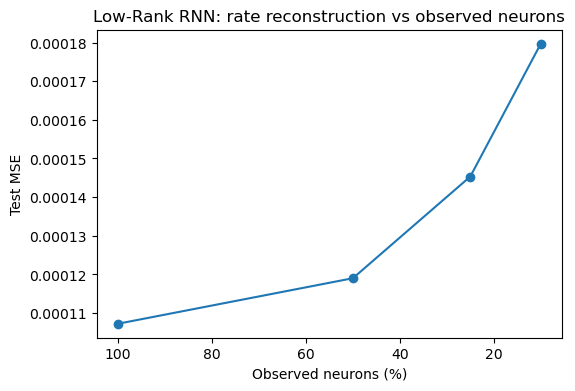

In [9]:
# plot test MSE vs observed neurons

obs_numeric = [100, 50, 25, 10]
test_mse_vals = [results["100%"]["test_mse"],
                 results["50%"]["test_mse"],
                 results["25%"]["test_mse"],
                 results["10%"]["test_mse"]]

plt.figure(figsize=(6,4))
plt.plot(obs_numeric, test_mse_vals, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Observed neurons (%)")
plt.ylabel("Test MSE")
plt.title("Low-Rank RNN: rate reconstruction vs observed neurons")
plt.show()

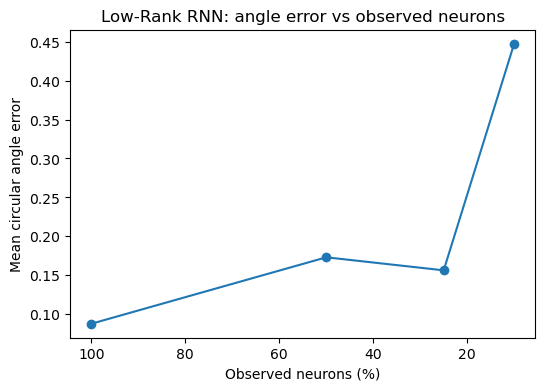

In [10]:
# plot angle error vs observed neurons

angle_err_vals = [results["100%"]["angle_err_test"],
                  results["50%"]["angle_err_test"],
                  results["25%"]["angle_err_test"],
                  results["10%"]["angle_err_test"]]

plt.figure(figsize=(6,4))
plt.plot(obs_numeric, angle_err_vals, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Observed neurons (%)")
plt.ylabel("Mean circular angle error")
plt.title("Low-Rank RNN: angle error vs observed neurons")
plt.show()

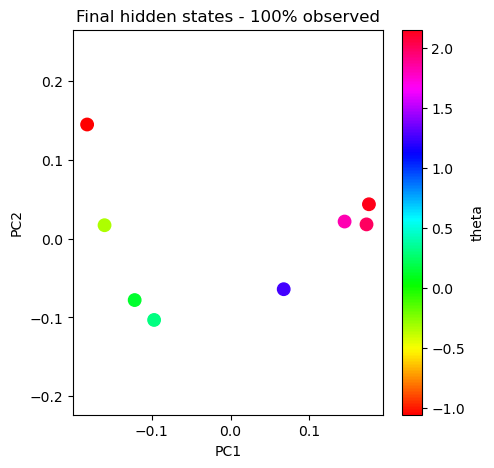

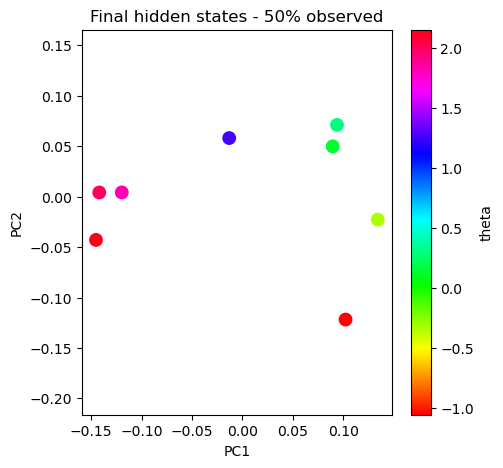

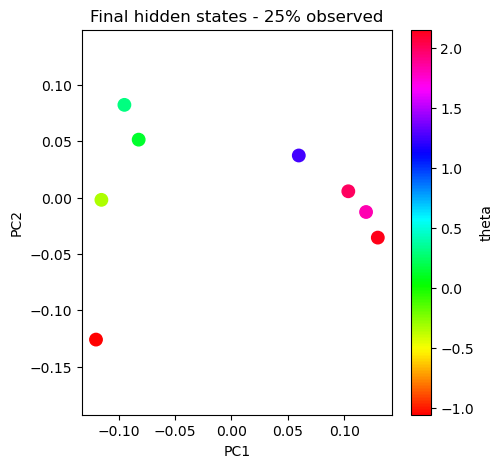

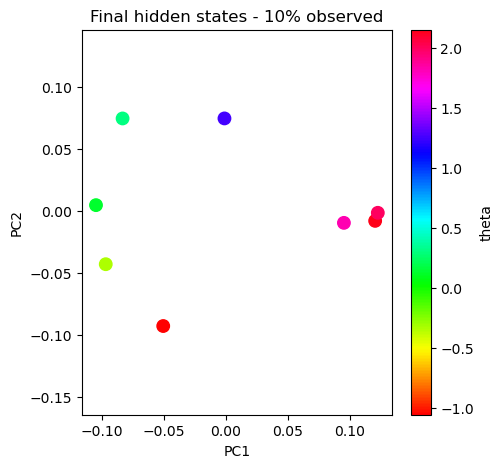

In [11]:
# compare final hidden states for each observation level

for label in OBS_LEVELS.keys():
    h_test = results[label]["h_test"]

    h_last = h_test[:, -1, :].cpu().numpy()
    theta_last = results[label]["Y_theta_test"][:, -1]

    pca = PCA(n_components=2)
    h_last_pca = pca.fit_transform(h_last)

    plt.figure(figsize=(5,5))
    sc = plt.scatter(h_last_pca[:,0], h_last_pca[:,1], c=theta_last, cmap="hsv", s=80)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Final hidden states - {label} observed")
    plt.colorbar(sc, label="theta")
    plt.axis("equal")
    plt.show()

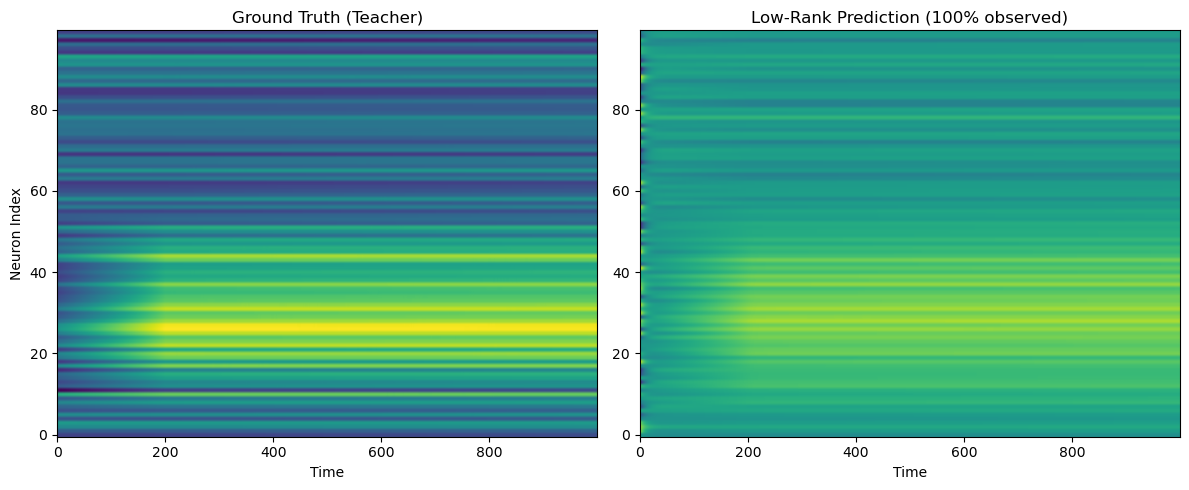

In [12]:
# reconstruction heatmap for one trial

selected_level = "100%"   # choose one observation level to inspect

X_key = OBS_LEVELS[selected_level]
X = data[X_key]

X_test = torch.tensor(X[test_idx], dtype=torch.float32)
Y_test = torch.tensor(Y[test_idx], dtype=torch.float32)

model = results[selected_level]["model"]
model.eval()

with torch.no_grad():
    y_pred_test, _ = model(X_test)

trial_idx = 0
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(Y_test[trial_idx].cpu().T, aspect='auto', origin='lower', cmap='viridis')
ax[0].set_title("Ground Truth (Teacher)")
ax[0].set_ylabel("Neuron Index")
ax[0].set_xlabel("Time")

ax[1].imshow(y_pred_test[trial_idx].cpu().T, aspect='auto', origin='lower', cmap='viridis')
ax[1].set_title(f"Low-Rank Prediction ({selected_level} observed)")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

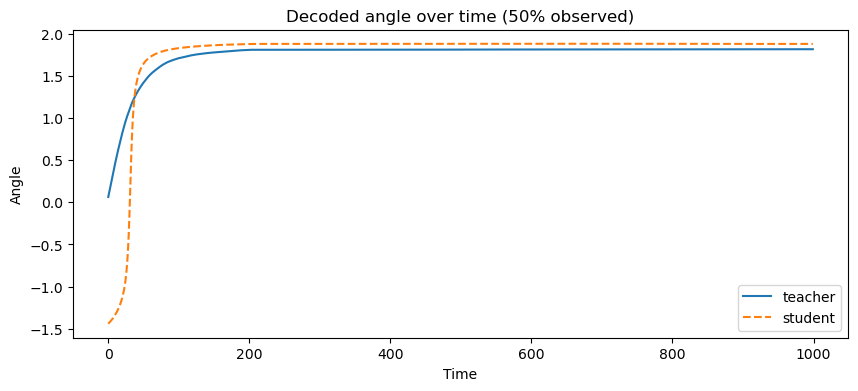

In [13]:
# predicted-vs-true angle plot for one trial, for each observation level

selected_level = "50%"
trial_idx = 0

theta_true = results[selected_level]["Y_theta_test"][trial_idx]
theta_pred = results[selected_level]["theta_pred_test"][trial_idx]

plt.figure(figsize=(10,4))
plt.plot(theta_true, label="teacher")
plt.plot(theta_pred, "--", label="student")
plt.title(f"Decoded angle over time ({selected_level} observed)")
plt.xlabel("Time")
plt.ylabel("Angle")
plt.legend()
plt.show()

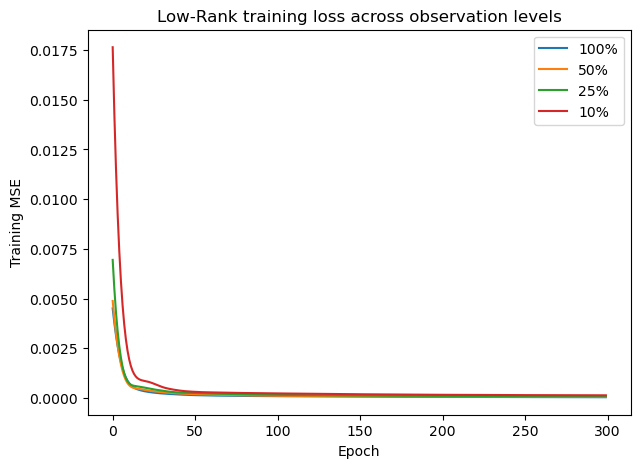

In [14]:
# training-loss curves for all observation levels

plt.figure(figsize=(7,5))
for label in OBS_LEVELS.keys():
    plt.plot(results[label]["losses"], label=label)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Low-Rank training loss across observation levels")
plt.legend()
plt.show()

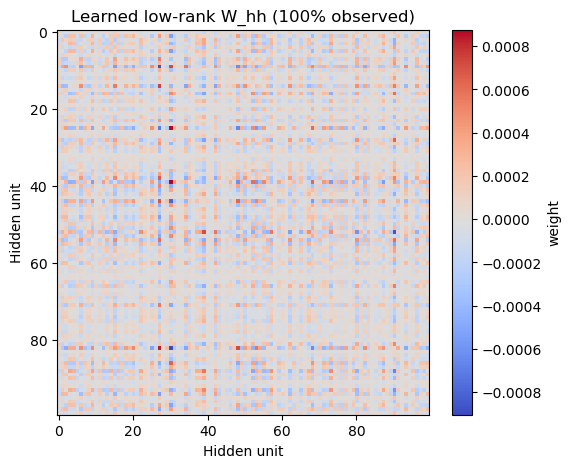

In [15]:
# low-rank-specific diagnostic 1:
# inspect the learned recurrent matrix for one observation level

selected_level = "100%"
W_hh = results[selected_level]["W_hh"]

plt.figure(figsize=(6,5))
plt.imshow(W_hh, aspect="auto", cmap="coolwarm")
plt.colorbar(label="weight")
plt.xlabel("Hidden unit")
plt.ylabel("Hidden unit")
plt.title(f"Learned low-rank W_hh ({selected_level} observed)")
plt.show()

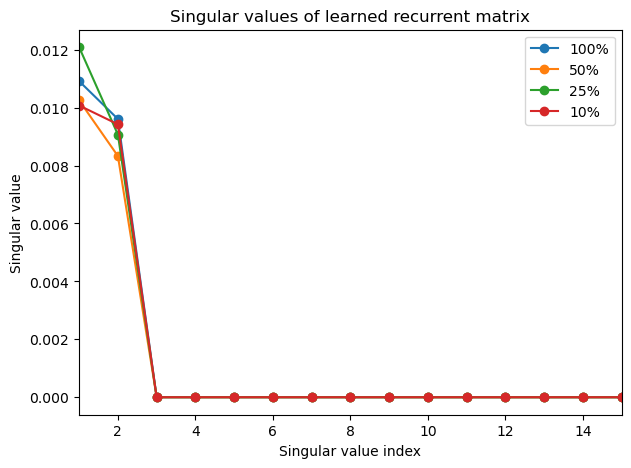

In [16]:
# low-rank-specific diagnostic 2:
# singular values of the learned recurrent matrix

plt.figure(figsize=(7,5))
for label in OBS_LEVELS.keys():
    svals = results[label]["singular_values"]
    plt.plot(np.arange(1, len(svals)+1), svals, marker="o", label=label)

plt.xlabel("Singular value index")
plt.ylabel("Singular value")
plt.title("Singular values of learned recurrent matrix")
plt.xlim(1, 15)
plt.legend()
plt.show()